<a href="https://colab.research.google.com/github/tako2go/StudentCup2026/blob/main/StudentCompe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ls /content/drive/MyDrive/StudentCup2026/data/

In [5]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 54.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=2e6afd74579b05c53a71ce2456647505653e23b0fea8c08f7dcfbac5dd3e63b0
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

In [7]:

base_folder = "/content/drive/MyDrive/StudentCup2026/data/"
train = pd.read_csv(base_folder + "train.csv")
test = pd.read_csv(base_folder + "test.csv")

train.columns

describe = pd.read_csv(base_folder + "description.csv")
describe


,カラム名,説明
0,企業ID,企業固有のNo
1,企業名,架空の企業名
2,従業員数,連結従業員数
3,業界,製造、商社、金融、機械、アパレル、エネルギー、IT・・・等
4,上場種別,マーケット名
5,特徴,"BtoB,BtoCなど"
6,企業概要,企業の事業内容等
7,組織図,階層型組織図（フォーマットは統一されていない）
8,事業所数,企業が保有する事務所の数
9,工場数,企業が保有する工場の数


In [8]:
print(train.info())
print(train.columns[train.notna().sum() >= 742])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   企業ID                742 non-null    int64  
 1   企業名                 742 non-null    object 
 2   従業員数                742 non-null    int64  
 3   業界                  742 non-null    object 
 4   上場種別                742 non-null    object 
 5   特徴                  740 non-null    object 
 6   企業概要                742 non-null    object 
 7   組織図                 742 non-null    object 
 8   事業所数                726 non-null    float64
 9   工場数                 339 non-null    float64
 10  店舗数                 139 non-null    float64
 11  資本金                 736 non-null    float64
 12  総資産                 742 non-null    int64  
 13  流動資産                742 non-null    int64  
 14  固定資産                742 non-null    int64  
 15  負債                  742 non-null    int64  
 16  短期借入金   

In [17]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb


feature = ['従業員数', '上場種別', '事業所数', '工場数', '店舗数', '資本金', '総資産', '流動資産', '固定資産', '負債', '短期借入金', '長期借入金', '純資産', '自己資本', '売上', '営業利益', '経常利益', '当期純利益', '営業CF', '減価償却費', '運転資本変動', '投資CF', '有形固定資産変動', '無形固定資産変動(ソフトウェア関連)', 'アンケート１', 'アンケート２', 'アンケート３', 'アンケート４', 'アンケート５', 'アンケート６', 'アンケート７', 'アンケート８', 'アンケート９', 'アンケート１０', 'アンケート１１']
# feature = [ '売上','当期純利益', ]
target = '購入フラグ'
X = train[feature]
y = train[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# X_train = train[feature]
# y_train = train[target]
# X_test = test[feature]

for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
X_train = X_train.dropna(axis=1)
X_test = X_test.dropna(axis=1)

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight='balanced',
    verbosity=-1
)

model.fit(X_train, y_train)

# 購入=1になる確率
y_prob = model.predict_proba(X_test)[:, 1]

# 閾値探索
best_f1 = 0
best_threshold = 0.5

for threshold in np.arange(0.01, 1.00, 0.01):
    y_pred = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

y_pred = (y_prob >= best_threshold).astype(int)


Best threshold: 0.15000000000000002
Best F1: 0.5945945945945946


In [10]:
def add_feature(df, name, value):
  df[name] = value


In [11]:
logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit(deisp = 0)

print(result.summary())

y_train_pred_prob = result.predict(X_train)
y_test_pred_prob = result.predict(X_test)
y_train_pred = (y_train_pred_prob >= 0.22).astype(int)
y_test_pred = (y_test_pred_prob >= 0.22).astype(int)

Optimization terminated successfully.
         Current function value: 0.462704
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  購入フラグ   No. Observations:                  593
Model:                          Logit   Df Residuals:                      565
Method:                           MLE   Df Model:                           27
Date:                Wed, 19 Aug 2026   Pseudo R-squ.:                  0.1624
Time:                        08:54:07   Log-Likelihood:                -274.38
converged:                       True   LL-Null:                       -327.57
Covariance Type:            nonrobust   LLR p-value:                 2.256e-11
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.3326      0.749      0.444      0.657      -1.136       1.801
従業員数 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: deisp. After release 0.14, this will raise.
  warnings.warn(


In [ ]:
X_train.shape

In [ ]:
pd.set_option('display.max_columns', 100)
train.head(3)
train['上場種別'].unique()

--- 混合行列 ---
[[73 40]
 [12 24]]




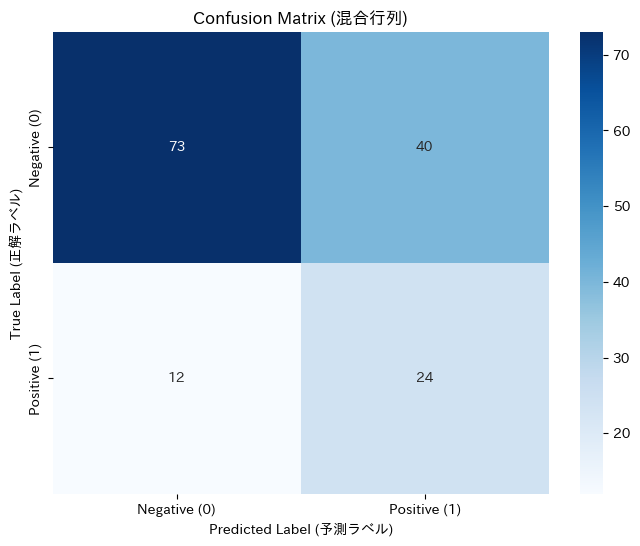

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

print("--- 混合行列 ---")
print(cm)
print("\n")


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label (予測ラベル)')
plt.ylabel('True Label (正解ラベル)')
plt.title('Confusion Matrix (混合行列)')
plt.show()

In [13]:
def Calc_Metrics(answer, pred):
  # 適合率 (Precision): 陽性と予測した中で、実際に陽性だった割合
  recision = precision_score(answer, pred)

  # 再現率 (Recall): 実際の陽性のうち、正しく陽性と予測できた割合
  recall = recall_score(answer, pred)

  # F1スコア: 適合率と再現率の調和平均
  f1 = f1_score(answer, pred)
  return recision, recall, f1

In [17]:
f1List = []
for threshold in np.arange(0.1, 0.5, 0.001):
    y_test_pred = (y_test_pred_prob >= threshold).astype(int)
    precision, recall, f1 =  Calc_Metrics(y_test, y_test_pred)
    f1List.append(f1)
    print(f"閾値: {threshold:.2f}")
    print("--- 各種評価指標 ---")
    print(f"適合率 (Precision): {precision:.4f}")
    print(f"再現率 (Recall):    {recall:.4f}")
    print(f"F1スコア (F1 Score): {f1:.4f}")
    print("\n")
f1max = max(f1List)
print(f1List.index(f1max))
print("   f1Max:", f1max)

In [ ]:
sample_submit = pd.read_csv(base_folder + "sample_submit.csv", header=None)
sample_submit.iloc[:, 1] = y_test_pred
sample_submit.to_csv("submit.csv", index=False, header=False)